Importing libraries and loading dataset

In [26]:
import pandas as pd
import numpy as np
import plotly.io as pio
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency


In [27]:
file_path = r"C:\Users\Ecem\Desktop\TIL\1. TIL6022 - Python\Project\df_clean_final_subQ5.csv"

dfulla = pd.read_csv(file_path)

Last preparation of the data for the analysis

In [28]:
# Dropping missing values in key fields
df = df.dropna(subset=["Volume_MIO_TKM", "train_share", "wagon_share"]).copy()

# Estimating commodity × consignment volumes (MIO_TKM)
# Using proportional assumption: shares × total volume
df["Est_train_MIO_TKM"] = df["Volume_MIO_TKM"] * df["train_share"]
df["Est_wagon_MIO_TKM"] = df["Volume_MIO_TKM"] * df["wagon_share"]

# Removing rows where both train and wagon are zero
df = df[(df["Est_train_MIO_TKM"] > 0) | (df["Est_wagon_MIO_TKM"] > 0)].copy()

print(f"Cleaned dataset shape: {df.shape}")
print(f"Commodities covered: {df['NST2007_desc'].nunique()}")


#Aggregation of the data
agg = (
    df.groupby("NST2007_desc")[["Est_train_MIO_TKM", "Est_wagon_MIO_TKM"]]
      .sum()
      .reset_index()
)

Cleaned dataset shape: (2557, 11)
Commodities covered: 20


Visualization

1. Heatmap

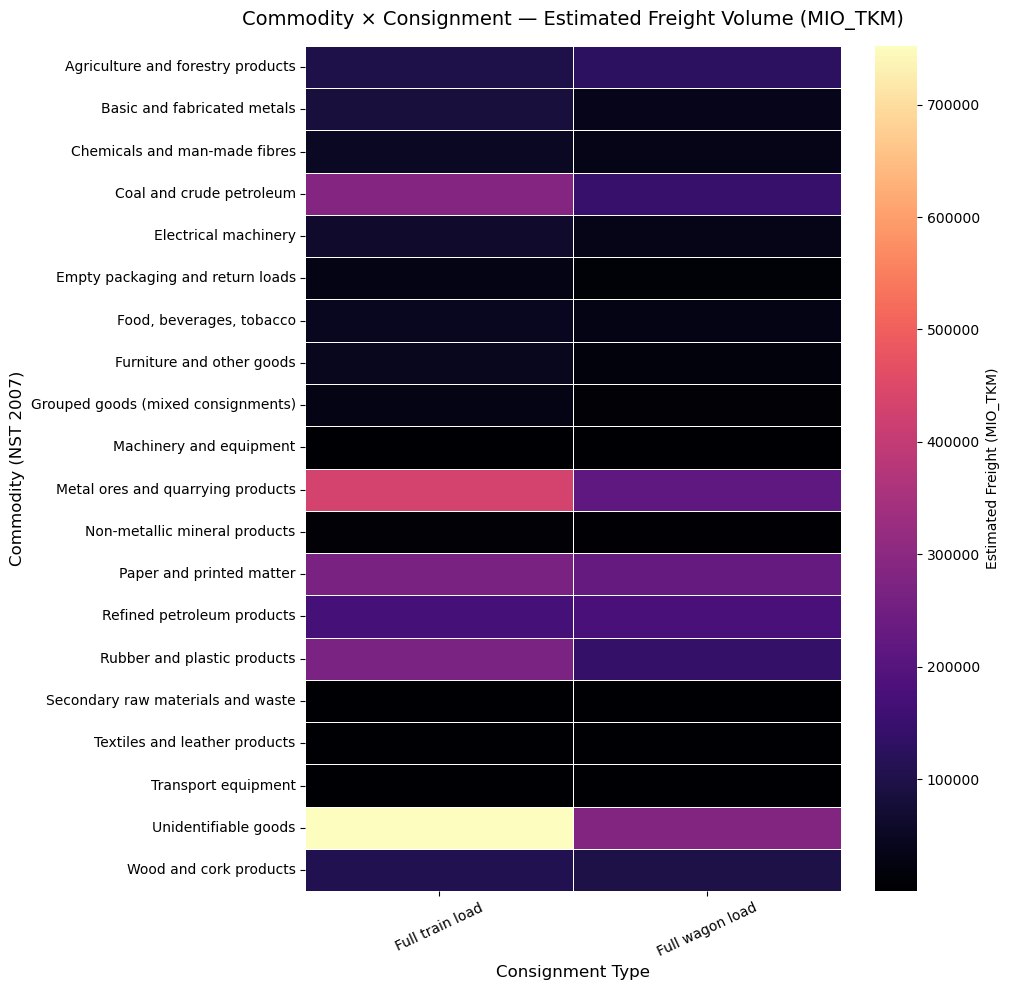

In [31]:
#Heatmap 

# Creating pivot table
heat_pivot = heatmap_long.pivot_table(
    index="NST2007_desc",
    columns="Consignment_Type",
    values="MIO_TKM",
    aggfunc="mean"
)

# Setting plot size
plt.figure(figsize=(10, 10))

# Create-ing heatmap
sns.heatmap(
    heat_pivot,
    cmap="magma",       
    linewidths=0.5,
    linecolor="white", 
    fmt=".1f",
    cbar_kws={"label": "Estimated Freight (MIO_TKM)"}
)

# Titles and labels
plt.title("Commodity × Consignment — Estimated Freight Volume (MIO_TKM)", fontsize=14, pad=15)
plt.xlabel("Consignment Type", fontsize=12)
plt.ylabel("Commodity (NST 2007)", fontsize=12)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

2. Stacked Bar Chart

In [25]:
# Stacked Bar — Consignment shares by commodity
row_norm = (
    agg.set_index("NST2007_desc")
       .pipe(lambda d: d.div(d.sum(axis=1).replace(0, np.nan), axis=0))
       .reset_index()
)
stack_share = row_norm.melt(
    id_vars="NST2007_desc",
    var_name="Consignment_Type",
    value_name="Share"
)
stack_share["Consignment_Type"] = stack_share["Consignment_Type"].map({
    "Est_train_MIO_TKM": "Full train load",
    "Est_wagon_MIO_TKM": "Full wagon load"
})

custom_colors = ["#4d8fc5", "#c9e7fc"]

fig_bar = px.bar(
    stack_share,
    x="NST2007_desc",
    y="Share",
    color="Consignment_Type",
    barmode="stack",
    title="Consignment Type Share by Commodity — EU Aggregate",
    labels={"NST2007_desc": "Commodity (NST 2007)", "Share": "Share (0–1)"},
    color_discrete_sequence=custom_colors
)
fig_bar.update_layout(height=750, title_x=0.5, xaxis_tickangle=30, legend_title_text="Consignment Type")
fig_bar.show()

Hypothesis Test

In [32]:
# chi-square test — Independence between commodity & consignment

# Building contingency table (Commodity × Consignment)
contingency = agg.rename(columns={
    "Est_train_MIO_TKM": "Train",
    "Est_wagon_MIO_TKM": "Wagon"
}).set_index("NST2007_desc")[["Train", "Wagon"]]

chi2, p, dof, exp = chi2_contingency(contingency.values)

print("Chi-square test of independence")
print(f"Chi2 statistic : {chi2:.3f}")
print(f"Degrees freedom: {dof}")
print(f"P-value        : {p:.6f}")

if p < 0.05:
    print("Reject H₀: Commodity distribution and consignment type are NOT independent.")
else:
    print("Fail to reject H₀: No evidence of association at 5% significance.")

Chi-square test of independence
Chi2 statistic : 153137.458
Degrees freedom: 19
P-value        : 0.000000
Reject H₀: Commodity distribution and consignment type are NOT independent.
